# BhuvanFitter — gene-expression distribution fitting

Per-gene tools, imported from `bhuvanfitter.py` (the single source of truth).
`BhuvanFitter` supports two fit models via the same `fit()` / `hist()` interface:

- **`fit("fourparam")`** — fits a 4-parameter Gaussian to the 40-bin histogram by
  ordinary least squares and returns
  `gene, y0, A, x0, w, sumsquarevalue, ti_fourparam_sigma_dist, truncationindex,
  min, max, right, maxheight, rightheight, n_obs, fit_success`. The
  truncation-index metrics use `x_max` (default = observed max):
  **`ti_fourparam_sigma_dist`** = `(x_max − x0) / (w/√2)` and **`truncationindex`**
  = `rightheight / maxheight`, with the fitted curve's interval-minimum subtracted
  from both, so it is **bounded to [0, 1]** (NaN only for a flat fitted curve).
- **`fit("kde")`** — runs a bin-independent Gaussian KDE and detects its modes
  (reusing `gene_peaks`), returning `gene, n_peaks, peaks, bw_method, n_obs,
  fit_success`, where `peaks` is `{value: {"height", "prominence"}}`.

`hist(lines=["fourparam", "kde"])` overlays either/both fitted curves on the
histogram (the KDE scaled to bin counts, with markers at detected peaks), but
only after the corresponding `fit` has been run.

## 1. Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The fitting library is the single source of truth (bhuvanfitter.py) — the
# model, the BhuvanFitter class, and gene_peaks all live there.
from bhuvanfitter import BhuvanFitter, gene_peaks

## 2. The 4-Parameter Gaussian Model

$$y = y_0 + A \cdot \exp\!\left(-\left(\frac{x - x_0}{w}\right)^2\right)$$

| Parameter | Meaning |
|---|---|
| `y0` | Baseline offset |
| `A`  | Amplitude (peak height above baseline) |
| `x0` | Centre of the peak |
| `w`  | Width parameter (`w = σ√2`) |

Lives in `bhuvanfitter.py` as the module-level `_fourparam_gaussian` (module
level because `scipy.optimize.curve_fit` needs a plain picklable callable). It is
imported above with `BhuvanFitter` — do **not** redefine it here, or the inline
copy will shadow the import and break (it would need its own `curve_fit` import).

## 3. The `BhuvanFitter` Class

The main interface, imported from `bhuvanfitter.py` (cell 1). It cleans the data,
caches a 40-bin histogram, and dispatches fits through `fit(model)`:

- `fit("fourparam")` — 4-parameter Gaussian by ordinary least squares + the
  truncation-index metrics.
- `fit("kde")` — Gaussian KDE mode detection (reuses `gene_peaks`).

`hist(lines=[...])` overlays any fits that have been run. All analysis logic lives
in the module so the notebook, `generate_fourparam_stats.py`, and
`generate_peaks.py` share one implementation — keep it imported, not redefined.

## 4. Example

A quick synthetic check: fit a Gaussian sample and overlay the fitted curve.

In [10]:
fourparam_df = pd.read_csv("worm_fourparam_table_excluded_at_or_below_-1.csv")
master = pd.read_csv('worm.csv').set_index('strain')
master = master.T

# Minimum post-exclusion samples for a gene's fit to be trusted. The generator's
# MIN_OBS=10 is too low for a 4-param fit to a 40-bin histogram (SD error ~24% at n=10);
# 30 gives ~13% SD error. Filtering here is identical to regenerating the table with this
# floor, since a gene's fit doesn't depend on MIN_OBS once n_obs clears it.
MIN_OBS = 30


def select(param):
    """Filtered column for plotting: fit_success genes with 0 < truncationindex < 1
    and n_obs >= MIN_OBS, NaNs dropped. This is the single place to change the shared filter."""
    mask = (fourparam_df['fit_success'] == True) & (fourparam_df['truncationindex'] > 0) & (fourparam_df['truncationindex'] < 1) & (fourparam_df['n_obs'] >= MIN_OBS)
    return fourparam_df.loc[mask, param].dropna()


def plot_param_hist(param, *, color='skyblue', bins=40, log=False):
    """Log-y histogram of `param` over the genes returned by select(). Returns the
    plotted data so callers can print counts / stats."""
    data = select(param)

    # Filtering funnel — mirrors select(), one print per stage.
    after_success = fourparam_df[fourparam_df['fit_success'] == True]
    after_nan = after_success[after_success[param].notna()]
    after_trunc_lower = after_nan[after_nan['truncationindex'] > 0]
    after_trunc_upper = after_trunc_lower[after_trunc_lower['truncationindex'] < 1]
    after_nobs = after_trunc_upper[after_trunc_upper['n_obs'] >= MIN_OBS]
    print(f"Total genes in master:            {master.shape[1]}")
    print(f"Total genes in fourparam_df:      {len(fourparam_df)}")
    print(f"After fit_success == True:        {len(after_success)}")
    print(f"After dropping NaN {param}: {len(after_nan)}")
    print(f"After truncationindex > 0:        {len(after_trunc_lower)}")
    print(f"After truncationindex < 1:        {len(after_trunc_upper)}")
    print(f"After n_obs >= {MIN_OBS}:              {len(after_nobs)}")

    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=bins, color=color, edgecolor='black')
    plt.title(f'Histogram of {param}')
    plt.xlabel(param)
    plt.ylabel('Frequency (Log Scale)' if log else 'Frequency')
    if log:
        plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    return data


def plot_gene_stat_hist(stat='mean', source='full', *, color=None, bins=40):
    """One-line histogram, over the filtered genes (select()), of a per-gene expression
    summary. Returns the plotted Series.
      stat   : 'mean' or 'std'
      source : 'full'  -> computed from `master` over ALL samples (incl. the -1 floor)
               'table' -> the post-exclusion fourparam_df[stat] column (only > -1 samples)
    Pair mean/std calls with the same `source` if you feed them to the scatter."""
    if source == 'full':
        values = getattr(master[select('gene')], stat)(axis=0).dropna()
    elif source == 'table':
        values = select(stat)
    else:
        raise ValueError("source must be 'full' or 'table'")
    color = color or ('mediumseagreen' if stat == 'mean' else 'cornflowerblue')
    label = {'mean': 'average', 'std': 'standard deviation'}[stat]
    print(f"Number of filtered genes: {len(values)}")

    plt.figure(figsize=(10, 6))
    plt.hist(values, bins=bins, color=color, edgecolor='black')
    plt.title(f'Per-gene {label} expression ({source} samples, filtered genes)')
    plt.xlabel('Average expression' if stat == 'mean' else 'Standard deviation')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    return values

Total genes in master:            25849
Total genes in fourparam_df:      25849
After fit_success == True:        25838
After dropping NaN sumsquarevalue: 25838
After truncationindex > 0:        11077
After truncationindex < 1:        11062
After n_obs >= 30:              11062


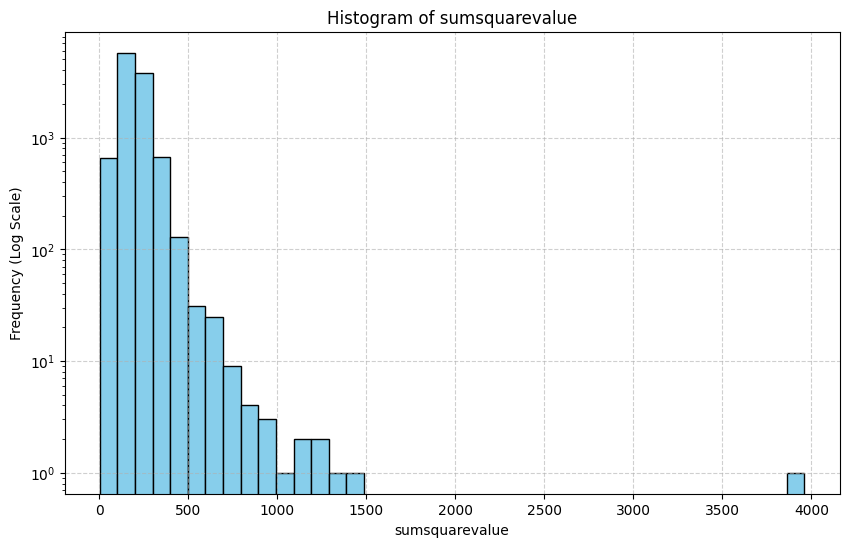

0        281.066268
4        146.262586
5        153.168776
6        124.493575
7        329.172616
            ...    
25838    100.517142
25839    410.363918
25842    217.765740
25847    201.338843
25848    276.690742
Name: sumsquarevalue, Length: 11062, dtype: float64

In [11]:
plot_param_hist('sumsquarevalue', log = True)

Total genes in master:            25849
Total genes in fourparam_df:      25849
After fit_success == True:        25838
After dropping NaN truncationindex: 25819
After truncationindex > 0:        11077
After truncationindex < 1:        11062
After n_obs >= 30:              11062


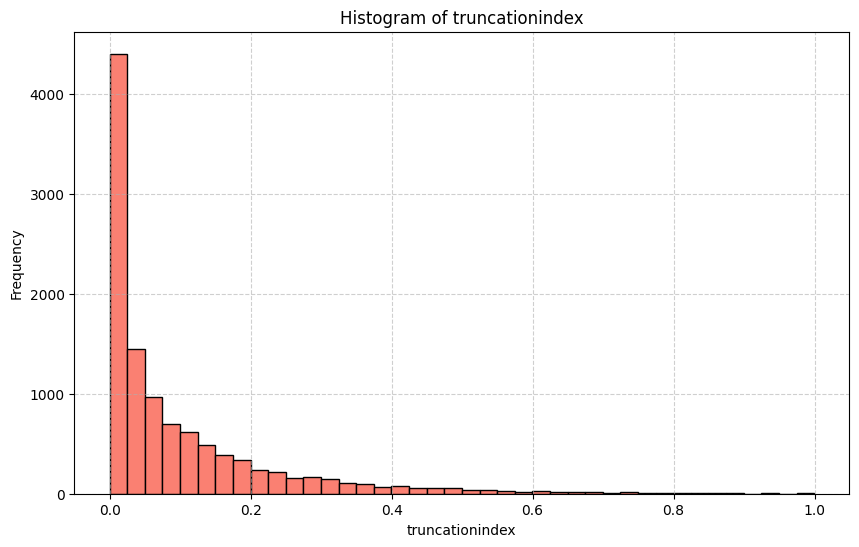

In [12]:
# Distribution of truncationindex across genes that fit successfully.
# truncationindex = rightheight / maxheight, with the fitted curve's interval-minimum
# baseline subtracted from both, so it is bounded to [0, 1] (0 = ceiling at the curve
# minimum, 1 = ceiling at the peak). NaN only for a flat fitted curve.
ti = plot_param_hist('truncationindex', color='salmon', log = False)

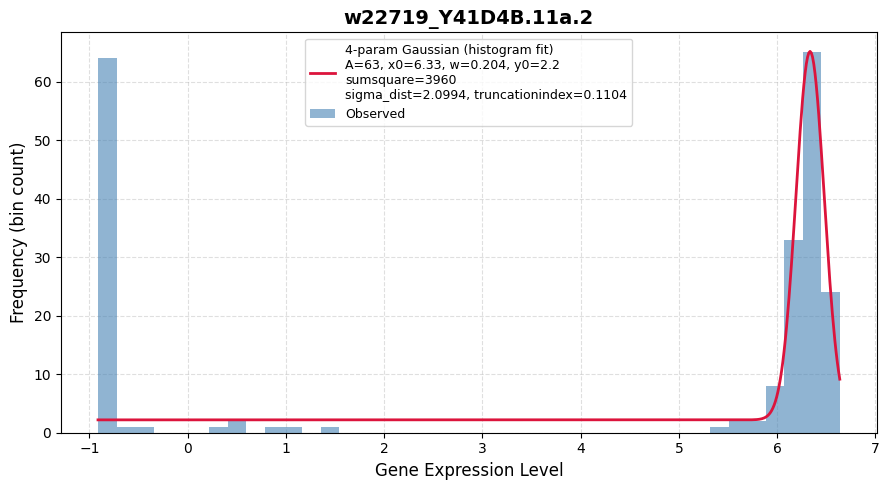

<Axes: title={'center': 'w22719_Y41D4B.11a.2'}, xlabel='Gene Expression Level', ylabel='Frequency (bin count)'>

In [13]:
fitter = BhuvanFitter(master['w22719_Y41D4B.11a.2'], "w22719_Y41D4B.11a.2")
fitter.fit("fourparam")     # runs the 4-param Gaussian
# fitter.fit("kde")           # runs the KDE fit
fitter.hist(lines=["fourparam"])   # overlay both

Number of filtered genes: 11062


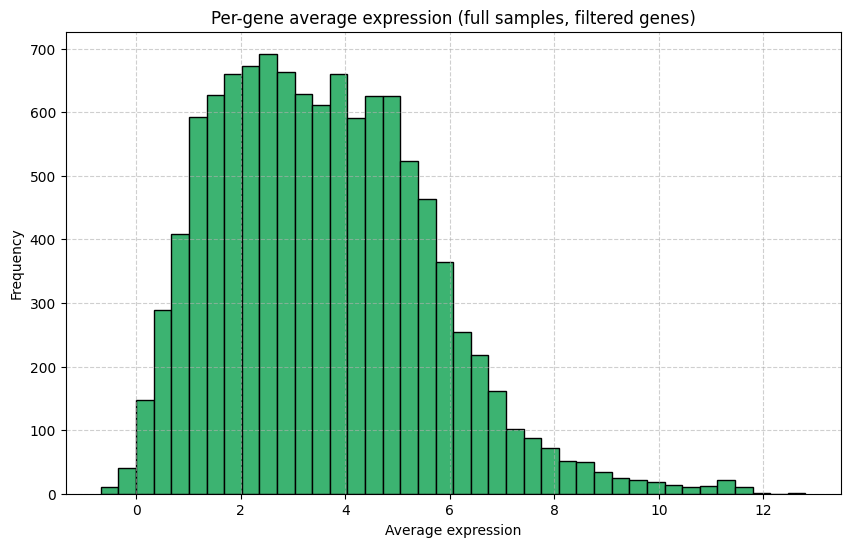

In [14]:
# Per-gene average expression over the filtered genes (source='full' = all 207 isolates
# incl. the -1 floor; use source='table' for the post-exclusion fourparam_df['mean']).
strain_avgs = plot_gene_stat_hist('mean')

Number of filtered genes: 11062


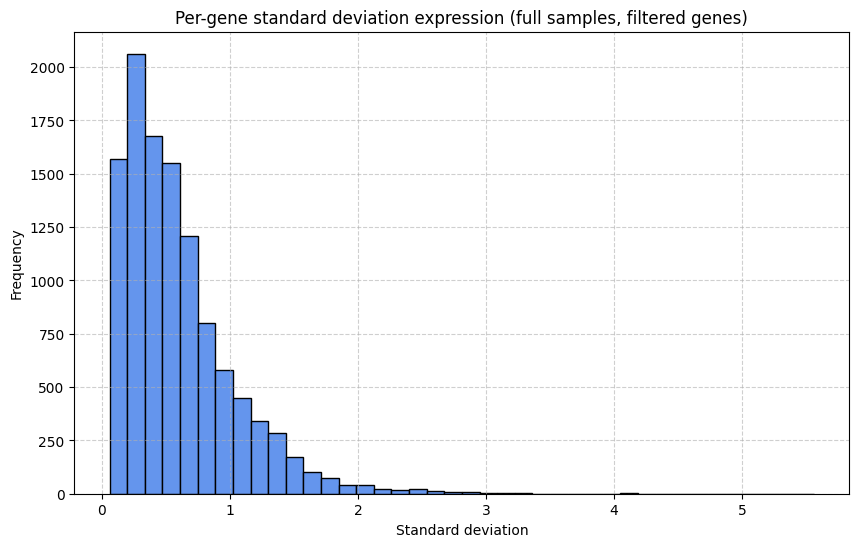

In [15]:
# Per-gene expression standard deviation over the same filtered genes. Keep the same
# `source` as the mean call above so the two align for the scatter below.
strain_sds = plot_gene_stat_hist('std')

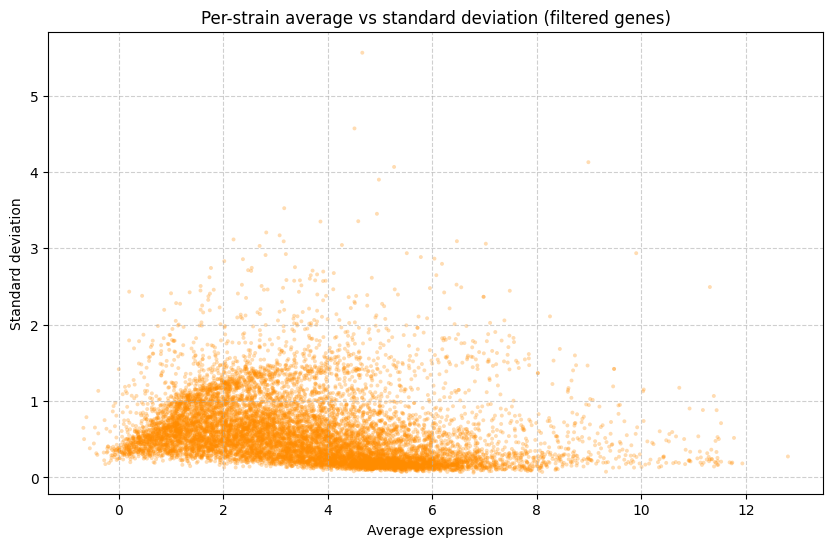

In [16]:
# Mean vs SD per filtered gene/strain column. strain_avgs and strain_sds are both
# indexed by gene from filtered_master, so they align by index for the scatter.
plt.figure(figsize=(10, 6))
plt.scatter(strain_avgs, strain_sds, s=8, alpha=0.3, color='darkorange', edgecolors='none')
plt.title('Per-strain average vs standard deviation (filtered genes)')
plt.xlabel('Average expression')
plt.ylabel('Standard deviation')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. Genes of interest — truncation-index ranges

`genes_of_interest.json` is now a list of 51 row-records (one per `grant_genes.csv`
row: human gene, worm gene, the 6 boolean phenotype flags, and fourparam transcript
IDs) rather than the old 4-separate-category layout, so it fully represents the
source table (including the two "Any" columns and human-gene names it used to
lose). For each category — the 6 flag-derived sets (`mco_any`, `mco_dev`,
`mco_behavior`, `lof_any`, `lof_dev`, `lof_behavior`) plus **mco_combined**,
**lof_combined**, and **all_combined** — summarise the `truncationindex` of the
listed transcripts (count + min / max / mean / median). Two versions: **without**
the shared analysis filter (any transcript that fit successfully) and **with** it
(`fit_success` & `0 < truncationindex < 1` & `n_obs >= MIN_OBS`).

In [ ]:
import json

with open('genes_of_interest.json') as f:
    goi = json.load(f)  # list of row-records: human_gene, worm_gene, 6 bool flags, transcript_ids

# One deduped, sorted transcript-ID list per boolean flag (flatten across records).
FLAGS = ['mcOE_any', 'mcOE_dev', 'mcOE_behavior', 'lof_any', 'lof_dev', 'lof_behavior']
cat_tx = {flag.lower().replace('mcoe_', 'mco_'):
          sorted({t for r in goi if r[flag] for t in r['transcript_ids']})
          for flag in FLAGS}
cat_tx['mco_combined'] = sorted(set(cat_tx['mco_dev']) | set(cat_tx['mco_behavior']))
cat_tx['lof_combined'] = sorted(set(cat_tx['lof_dev']) | set(cat_tx['lof_behavior']))
cat_tx['all_combined'] = sorted(set().union(*(set(cat_tx[k]) for k in
                          ['mco_dev', 'mco_behavior', 'lof_dev', 'lof_behavior'])))

CATEGORIES = ['mco_any', 'mco_dev', 'mco_behavior', 'mco_combined',
              'lof_any', 'lof_dev', 'lof_behavior', 'lof_combined', 'all_combined']

ti_by_gene = fourparam_df.set_index('gene')


def ti_range(transcripts, *, apply_filter):
    """truncationindex summary for one category's transcripts.
    apply_filter=False -> any transcript that fit successfully (has a ti);
    apply_filter=True  -> the shared filter (fit_success & 0<ti<1 & n_obs>=MIN_OBS)."""
    present = ti_by_gene.reindex([t for t in transcripts if t in ti_by_gene.index])
    if apply_filter:
        keep = ((present['fit_success'] == True) & (present['truncationindex'] > 0)
                & (present['truncationindex'] < 1) & (present['n_obs'] >= MIN_OBS))
    else:
        keep = (present['fit_success'] == True) & present['truncationindex'].notna()
    ti = present.loc[keep, 'truncationindex']
    return {'n_requested': len(transcripts), 'n_in_table': len(present), 'n_used': int(len(ti)),
            'min': ti.min(), 'max': ti.max(), 'mean': ti.mean(), 'median': ti.median()}


def ti_ranges(apply_filter):
    """Per-category truncationindex summary table (rows = categories)."""
    return pd.DataFrame({c: ti_range(cat_tx[c], apply_filter=apply_filter)
                         for c in CATEGORIES}).T

In [18]:
# WITHOUT the shared filter: every transcript that fit successfully counts
# (includes truncationindex == 0 or 1 and low-n_obs genes).
ti_ranges(apply_filter=False)

,n_requested,n_in_table,n_used,min,max,mean,median
mco_dev,42.0,42.0,42.0,0.0,0.604049,0.063025,0.000106
mco_behavior,13.0,13.0,13.0,0.0,0.402412,0.063480,0.000000
mco_combined,42.0,42.0,42.0,0.0,0.604049,0.063025,0.000106
lof_dev,28.0,28.0,28.0,0.0,0.364503,0.046306,0.001845
lof_behavior,23.0,23.0,23.0,0.0,0.364503,0.031167,0.000000
lof_combined,48.0,48.0,48.0,0.0,0.364503,0.034352,0.000000
all_combined,69.0,69.0,69.0,0.0,0.604049,0.053001,0.000885


In [19]:
# WITH the shared filter: fit_success & 0 < truncationindex < 1 & n_obs >= MIN_OBS.
ti_ranges(apply_filter=True)

,n_requested,n_in_table,n_used,min,max,mean,median
mco_dev,42.0,42.0,21.0,0.000212,0.604049,0.126050,0.039655
mco_behavior,13.0,13.0,6.0,0.000212,0.402412,0.137539,0.025031
mco_combined,42.0,42.0,21.0,0.000212,0.604049,0.126050,0.039655
lof_dev,28.0,28.0,17.0,0.000885,0.364503,0.076268,0.013845
lof_behavior,23.0,23.0,7.0,0.006931,0.364503,0.102405,0.033200
lof_combined,48.0,48.0,23.0,0.000885,0.364503,0.071691,0.025904
all_combined,69.0,69.0,36.0,0.000212,0.604049,0.101585,0.033681
